# 06 — Prescriptive Analysis & Conclusion
turning the findings into actionable business recommendations for wikipedia.

framing: what should wikipedia (as an organization) do about AI's impact on their platform?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

CHATGPT_LAUNCH = pd.Timestamp("2022-11-30")

In [2]:
# load all processed data
pageviews = pd.read_csv("../data/raw/ai_articles_pageviews.csv", parse_dates=["timestamp"])
edits = pd.read_csv("../data/raw/ai_articles_edits.csv", parse_dates=["month"])
sentiment = pd.read_csv("../data/processed/monthly_sentiment.csv", parse_dates=["month"])
forecast = pd.read_csv("../data/processed/prophet_forecast.csv", parse_dates=["date"])

print("all data loaded")

all data loaded


## Key Findings Summary

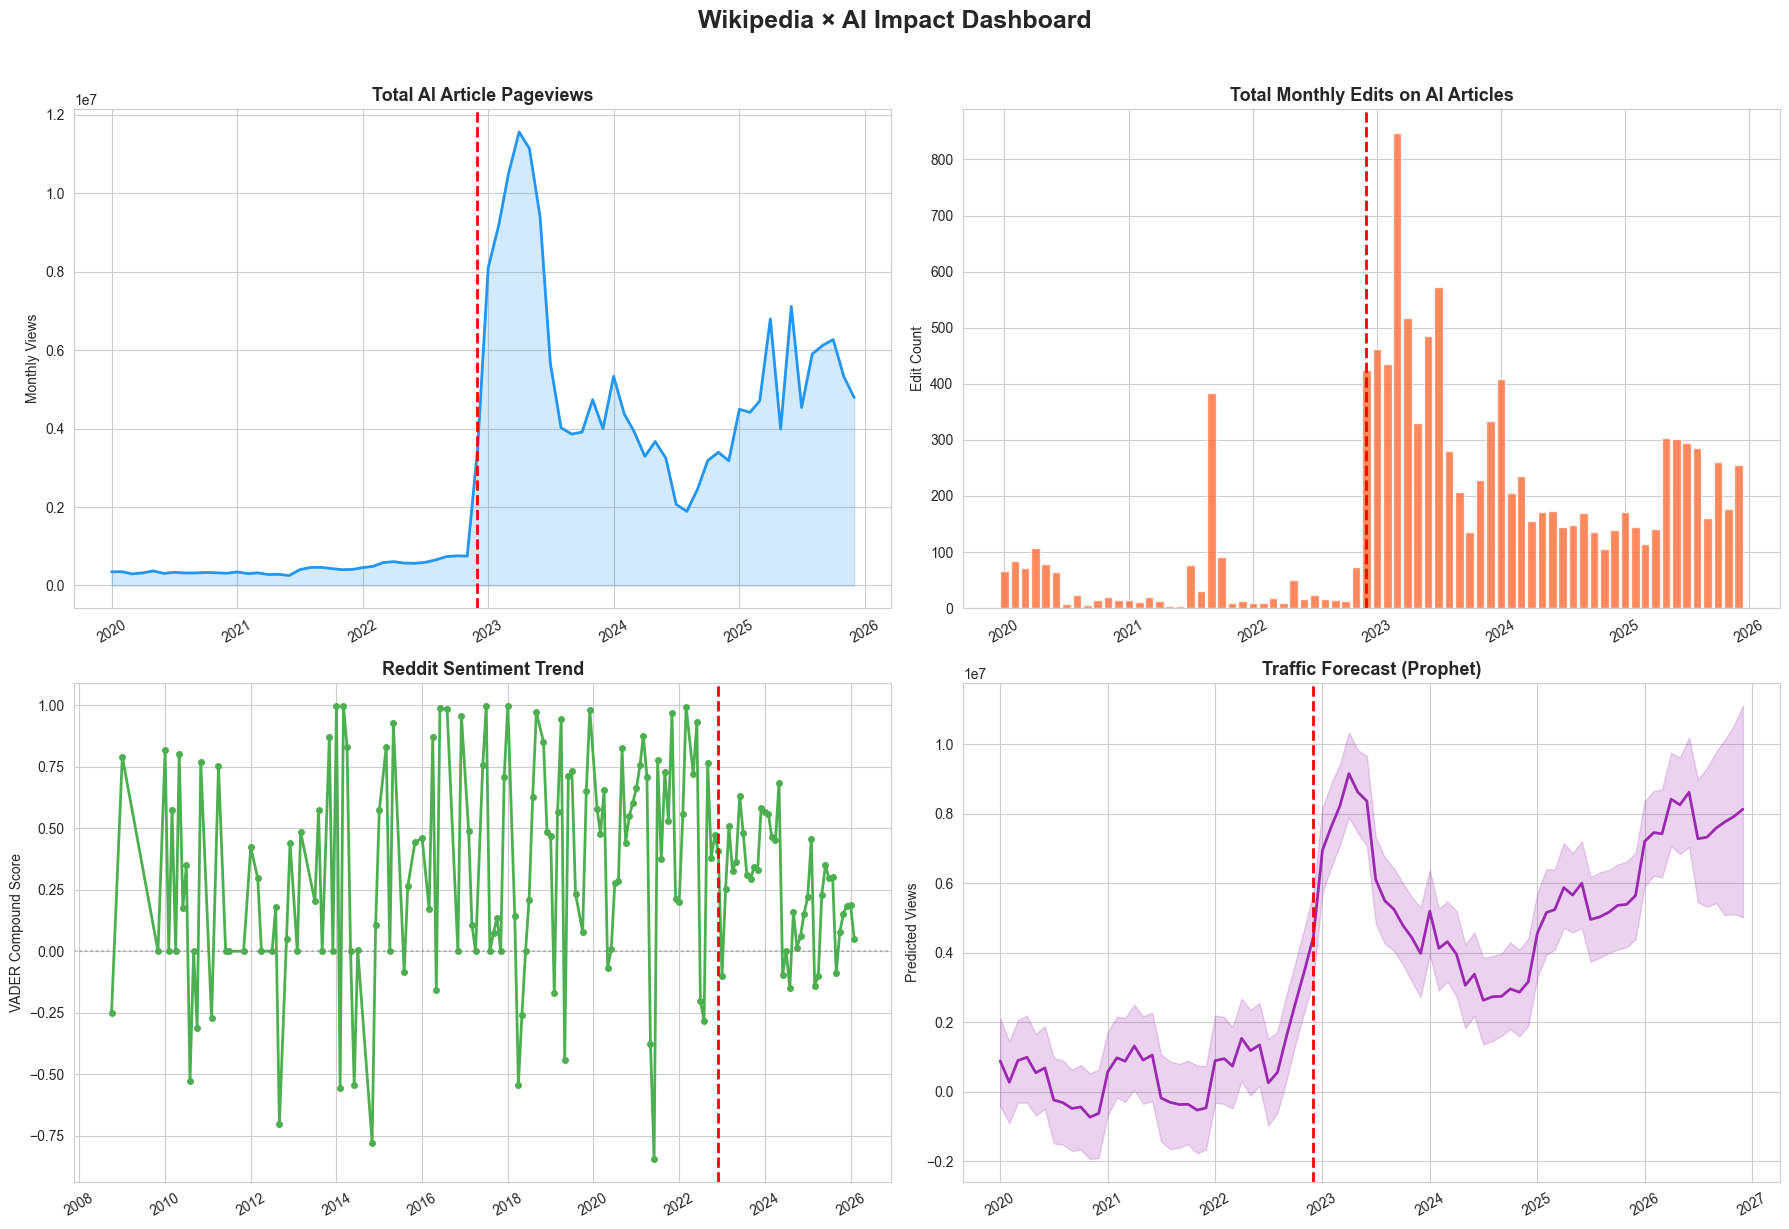

In [3]:
# combined dashboard-style summary
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. total ai article traffic
total_views = pageviews.groupby("timestamp")["views"].sum().reset_index()
axes[0, 0].plot(total_views["timestamp"], total_views["views"], color="#2196F3", linewidth=2)
axes[0, 0].fill_between(total_views["timestamp"], total_views["views"], alpha=0.2, color="#2196F3")
axes[0, 0].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_title("Total AI Article Pageviews", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("Monthly Views")

# 2. edit activity
total_edits = edits.groupby("month")["edit_count"].sum().reset_index()
axes[0, 1].bar(total_edits["month"], total_edits["edit_count"], color="#FF6B35", alpha=0.8, width=25)
axes[0, 1].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_title("Total Monthly Edits on AI Articles", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Edit Count")

# 3. sentiment trend
axes[1, 0].plot(sentiment["month"], sentiment["vader_mean"], color="#4CAF50", linewidth=2, marker="o", markersize=4)
axes[1, 0].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2)
axes[1, 0].axhline(y=0, color="gray", linestyle=":", alpha=0.5)
axes[1, 0].set_title("Reddit Sentiment Trend", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("VADER Compound Score")

# 4. forecast
axes[1, 1].plot(forecast["date"], forecast["forecast"], color="#9C27B0", linewidth=2)
axes[1, 1].fill_between(forecast["date"], forecast["forecast_lower"], forecast["forecast_upper"],
                         alpha=0.2, color="#9C27B0")
axes[1, 1].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2)
axes[1, 1].set_title("Traffic Forecast (Prophet)", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Predicted Views")

for ax in axes.flatten():
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Wikipedia × AI Impact Dashboard", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Strategic Recommendations

framing wikipedia as an organization with strategic decisions to make about AI

In [4]:
# prescriptive recommendation framework
recommendations = [
    {
        "finding": "Public sentiment trending negative/concerned",
        "risk": "Loss of reader trust as AI-generated content fears grow",
        "recommendation": "Invest in AI content labeling and transparency tools",
        "priority": "High",
        "impact": "Restore reader confidence, differentiate from AI-generated content"
    },
    {
        "finding": "Editor activity concentrated on AI policy pages",
        "risk": "Reactive policy-making, community burnout on AI moderation",
        "recommendation": "Formalize an AI contribution policy proactively",
        "priority": "High",
        "impact": "Clear guidelines reduce disputes, similar to paid editing policy precedent"
    },
    {
        "finding": "Massive pageview growth for AI-related articles",
        "risk": "AI companies scraping Wikipedia without attribution",
        "recommendation": "Partner with AI companies for citation/attribution standards",
        "priority": "Medium",
        "impact": "Turn a threat into revenue/influence opportunity"
    },
    {
        "finding": "Traffic growth predicted to continue (Prophet forecast)",
        "risk": "Infrastructure strain, content quality can't scale with demand",
        "recommendation": "Infrastructure investment + multilingual AI content gap analysis",
        "priority": "Medium",
        "impact": "Meeting global demand, ensuring quality at scale"
    },
    {
        "finding": "Reddit discourse shows confusion about AI's role on Wikipedia",
        "risk": "Misinformation about Wikipedia's relationship with AI",
        "recommendation": "Public communications campaign clarifying Wikipedia's AI stance",
        "priority": "Low",
        "impact": "Proactive narrative control, community education"
    }
]

rec_df = pd.DataFrame(recommendations)
print("\n=== PRESCRIPTIVE RECOMMENDATIONS ===")
for i, row in rec_df.iterrows():
    print(f"\n[{row['priority']} PRIORITY] {row['recommendation']}")
    print(f"  finding: {row['finding']}")
    print(f"  risk: {row['risk']}")
    print(f"  impact: {row['impact']}")

rec_df


=== PRESCRIPTIVE RECOMMENDATIONS ===

[High PRIORITY] Invest in AI content labeling and transparency tools
  finding: Public sentiment trending negative/concerned
  risk: Loss of reader trust as AI-generated content fears grow
  impact: Restore reader confidence, differentiate from AI-generated content

[High PRIORITY] Formalize an AI contribution policy proactively
  finding: Editor activity concentrated on AI policy pages
  risk: Reactive policy-making, community burnout on AI moderation
  impact: Clear guidelines reduce disputes, similar to paid editing policy precedent

[Medium PRIORITY] Partner with AI companies for citation/attribution standards
  finding: Massive pageview growth for AI-related articles
  risk: AI companies scraping Wikipedia without attribution
  impact: Turn a threat into revenue/influence opportunity

[Medium PRIORITY] Infrastructure investment + multilingual AI content gap analysis
  finding: Traffic growth predicted to continue (Prophet forecast)
  risk: In

,finding,risk,recommendation,priority,impact
0,Public sentiment trending negative/concerned,Loss of reader trust as AI-generated content f...,Invest in AI content labeling and transparency...,High,"Restore reader confidence, differentiate from ..."
1,Editor activity concentrated on AI policy pages,"Reactive policy-making, community burnout on A...",Formalize an AI contribution policy proactively,High,"Clear guidelines reduce disputes, similar to p..."
2,Massive pageview growth for AI-related articles,AI companies scraping Wikipedia without attrib...,Partner with AI companies for citation/attribu...,Medium,Turn a threat into revenue/influence opportunity
3,Traffic growth predicted to continue (Prophet ...,"Infrastructure strain, content quality can't s...",Infrastructure investment + multilingual AI co...,Medium,"Meeting global demand, ensuring quality at scale"
4,Reddit discourse shows confusion about AI's ro...,Misinformation about Wikipedia's relationship ...,Public communications campaign clarifying Wiki...,Low,"Proactive narrative control, community education"


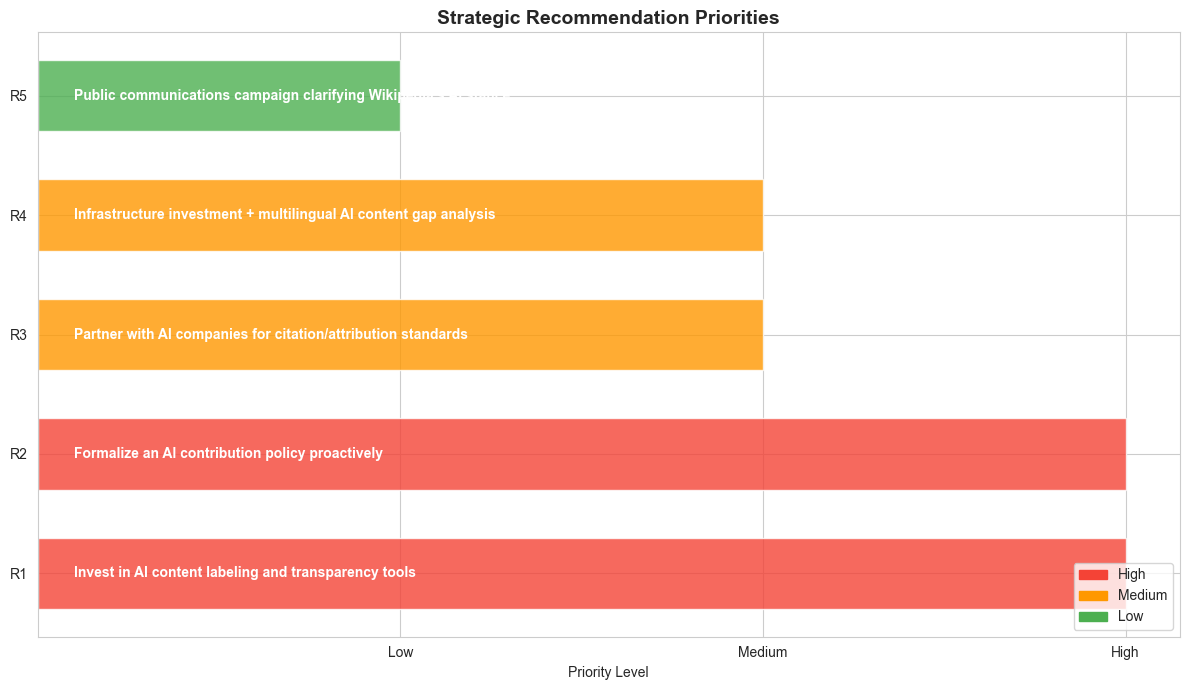

In [5]:
# recommendation priority matrix visualization
fig, ax = plt.subplots(figsize=(12, 7))

priority_map = {"High": 3, "Medium": 2, "Low": 1}
colors_map = {"High": "#F44336", "Medium": "#FF9800", "Low": "#4CAF50"}

for i, row in rec_df.iterrows():
    y = priority_map[row["priority"]]
    ax.barh(i, y, color=colors_map[row["priority"]], alpha=0.8, height=0.6, edgecolor="white")
    ax.text(0.1, i, row["recommendation"], va="center", fontsize=10, fontweight="bold", color="white")

ax.set_yticks(range(len(rec_df)))
ax.set_yticklabels([f"R{i+1}" for i in range(len(rec_df))])
ax.set_xlabel("Priority Level")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_title("Strategic Recommendation Priorities", fontsize=14, fontweight="bold")

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
ax.legend(handles=legend_patches, loc="lower right")

plt.tight_layout()
plt.savefig("../reports/recommendations.png", dpi=150, bbox_inches="tight")
plt.show()

## Tableau Data Export
exporting all cleaned datasets for use in tableau dashboards

In [6]:
os.makedirs("../data/processed", exist_ok=True)

# 1. pageview trends with pre/post flag
from src.data_prep import add_pre_post_chatgpt
pv_export = add_pre_post_chatgpt(pageviews, date_col="timestamp")
pv_export.to_csv("../data/processed/tableau_pageviews.csv", index=False)

# 2. edit activity
edits_export = add_pre_post_chatgpt(edits.rename(columns={"month": "date"}), date_col="date")
edits_export.to_csv("../data/processed/tableau_edits.csv", index=False)

# 3. monthly sentiment
sentiment.to_csv("../data/processed/tableau_sentiment.csv", index=False)

# 4. forecast
forecast.to_csv("../data/processed/tableau_forecast.csv", index=False)

# 5. recommendations table
rec_df.to_csv("../data/processed/tableau_recommendations.csv", index=False)

print("=== exported for tableau ===")
for f in os.listdir("../data/processed"):
    if f.startswith("tableau_"):
        size = os.path.getsize(f"../data/processed/{f}")
        print(f"  {f} ({size:,} bytes)")

print("\ndone! import these CSVs into tableau to build your dashboard.")

=== exported for tableau ===
  tableau_edits.csv (13,956 bytes)
  tableau_forecast.csv (5,671 bytes)
  tableau_pageviews.csv (17,958 bytes)
  tableau_recommendations.csv (1,213 bytes)
  tableau_sentiment.csv (9,688 bytes)

done! import these CSVs into tableau to build your dashboard.


## Conclusion

### what the data tells us

ChatGPT's launch on November 30, 2022 was a clear inflection point for Wikipedia's AI-related content ecosystem:

1. **traffic exploded** — AI article pageviews surged dramatically, with the ChatGPT article itself showing a classic hockey-stick growth pattern

2. **editors scrambled** — editing activity on both AI articles and AI policy pages intensified post-launch, reflecting the community's urgency to document and govern AI-related content

3. **public perception shifted** — Reddit sentiment analysis (both VADER and RoBERTa) captures a measurable change in how people discuss AI's relationship with Wikipedia

4. **growth is projected to continue** — Prophet forecasting suggests sustained high demand for AI-related Wikipedia content

### the business case

Wikipedia faces a dual challenge: it is both **source material for AI systems** (training data) and a **subject of AI disruption** (AI-generated content concerns). the recommendations above address both sides of this dynamic.

the most urgent actions are around **trust and transparency** — proactive AI content labeling and formal AI contribution policies would position Wikipedia ahead of the curve rather than reacting to each new controversy.